# California Traffic Collision Data Engineering & ETL Pipeline
**Tech Stack:** PySpark 3.5 | Python | Spark SQL | ETL Pipelines

## Executive Summary
This project processes and analyzes large-scale California Statewide Integrated Traffic Records System (SWITRS) crash data. Using Apache Spark and AWS S3, it cleans raw collision records, performs relational transformations, extracts high-risk traffic safety insights, and exports optimized datasets for BI dashboard integration.

## Problem Statement & Business Context
Traffic collision analysis is critical for municipal planning, emergency response optimization, and safety infrastructure investments. Traditional database systems struggle to process high-volume, multi-source crash records efficiently. This project builds a scalable ETL and analytics pipeline to extract actionable safety metrics from millions of raw incident records.

---

## Data Architecture & Pipeline Overview
1. **Ingestion:** Loading structured SWITRS incident tables (Collisions, Parties, Victims, Locations).
2. **Data Hygiene & Transformation:** Standardizing schemas, handling missing attributes, and normalizing temporal features using PySpark SQL.
3. **Exploratory & Spatial Analysis:** Aggregating high-density crash zones, environmental risk drivers, and temporal peaks.
4. **Targeted Storage:** Storing transformed analytical datasets directly into AWS S3 as partitioned CSV files for downstream BI dashboard consumption (Tableau/Power BI).

## Dataset Architecture & Relational Schema

The underlying dataset originates from a multi-table SWITRS database containing detailed California traffic incident records structured across four primary relational entities:

* **`collisions`**: Primary incident records capturing spatio-temporal coordinates, weather/lighting conditions, and overall crash severity.
* **`parties`**: Entity-level data detailing driver/party demographics, vehicle types, sobriety ratings, and fault indicators.
* **`victims`**: Individual-level injury tracking, seating positions, ejection metrics, and severity breakdown.
* **`case_id`**: Master metadata mapping table establishing relational integrity and cross-year indexing across crash records.

Environment Configuration & Data Lake Mount

In [1]:
# ==============================================================================
# Environment Configuration & Data Lake Mount
# ==============================================================================

# Mount Google Drive for persistent file storage access
from google.colab import drive
drive.flush_and_unmount()
drive.mount('/content/drive')

Mounted at /content/drive


Install Required Libraries

In [3]:
# ==============================================================================
# Install Core Data Engineering & Visualization Dependencies
# ==============================================================================

!pip install --quiet --no-deps pyspark==3.5.4 "pandas<2.3.0"

  Preparing metadata (setup.py) ... done


In [20]:
# ==============================================================================
# Pipeline Imports & Session Initialization
# ==============================================================================

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum, count, avg, when, to_date, date_format, year, hour
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType, TimestampType

# Initialize PySpark Session
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("CaliforniaTrafficCollisionETL")
    .getOrCreate()
)

## Stage 1: Scalable Data Ingestion & Schema Definition

In this phase, raw multi-table SWITRS incident datasets (`collisions`, `parties`, `victims`, and `case_ids`) are ingested into distributed PySpark DataFrames. Primary schema constraints are validated to ensure relational integrity prior to downstream ETL transformations.

In [3]:
# ==============================================================================
# Ingest Multi-Table SWITRS Collision Datasets
# ==============================================================================

base_path = "/content/drive/MyDrive/Traffic_Collision_Analysis"

# Ingest primary relational tables
collisions_df = spark.read.csv(f"{base_path}/sample_collisions.csv", header=True, inferSchema=True)
parties_df    = spark.read.csv(f"{base_path}/sample_parties.csv", header=True, inferSchema=True)
victims_df    = spark.read.csv(f"{base_path}/sample_victims.csv", header=True, inferSchema=True)
case_ids_df   = spark.read.csv(f"{base_path}/sample_case_ids.csv", header=True, inferSchema=True)

# Validate record counts across entities
print(f"Ingestion Metrics:")
print(f" - Collisions Records: {collisions_df.count():,}")
print(f" - Parties Records:    {parties_df.count():,}")
print(f" - Victims Records:    {victims_df.count():,}")
print(f" - Master Case IDs:    {case_ids_df.count():,}")

# Display target schema & initial sample preview
collisions_df.printSchema()
collisions_df.show(5)

Ingestion Metrics:
 - Collisions Records: 935,791
 - Parties Records:    1,866,917
 - Victims Records:    963,933
 - Master Case IDs:    942,433
root
 |-- case_id: double (nullable = true)
 |-- jurisdiction: double (nullable = true)
 |-- officer_id: string (nullable = true)
 |-- reporting_district: string (nullable = true)
 |-- chp_shift: string (nullable = true)
 |-- population: string (nullable = true)
 |-- county_city_location: integer (nullable = true)
 |-- county_location: string (nullable = true)
 |-- special_condition: double (nullable = true)
 |-- beat_type: string (nullable = true)
 |-- chp_beat_type: string (nullable = true)
 |-- chp_beat_class: string (nullable = true)
 |-- beat_number: string (nullable = true)
 |-- primary_road: string (nullable = true)
 |-- secondary_road: string (nullable = true)
 |-- distance: double (nullable = true)
 |-- direction: string (nullable = true)
 |-- intersection: double (nullable = true)
 |-- weather_1: string (nullable = true)
 |-- state_h

## Stage 2: Data Hygiene, Missing Value Analysis & Outlier Handling

In this stage, missing value profiles are calculated across primary data dimensions, critical categorical fields are standardized, and temporal features are extracted for downstream analytical queries.


In [5]:
# ==============================================================================
# Missing Value Profile Analysis
# ==============================================================================

#Check for Missing Values
from pyspark.sql.functions import isnan, when, count

# Count NULL values in every column
collisions_df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in collisions_df.columns
]).show()

#Count NaN values in every column
numeric_cols = [c for c, dtype in collisions_df.dtypes if dtype in ["double", "float"]]

collisions_df.select([
    count(when(isnan(col(c)), c)).alias(c)
    for c in numeric_cols
]).show()

+-------+------------+----------+------------------+---------+----------+--------------------+---------------+-----------------+---------+-------------+--------------+-----------+------------+--------------+--------+---------+------------+---------+-----------------------+---------------+-----------------+-----------+--------+-------------+---------------+--------+------------------+--------------+---------------+-----------+------------------------+----------------------+-------------+------------------------+-----------+-----------------+---------------------------+-----------------+------------+----------------+--------+--------------+-------------+--------------------+-----------------+--------------------+---------------+--------------------+-------------------------------+-------------------------+-------------------+--------------------------+------------------------------+-----------------------+------------------------+----------------------+-----------------------+-----------

In [6]:
# Total rows
row_count = collisions_df.count()

# Count NULLs across ALL columns in ONE query
null_counts = collisions_df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in collisions_df.columns
]).collect()[0].asDict()

# Get current columns to preserve order
current_cols = collisions_df.columns

# Determine columns to keep based on missing values (less than 50% null)
cols_to_keep_based_on_sparsity = [
    c for c, missing_cnt in null_counts.items()
    if missing_cnt < (row_count * 0.5)
]

# Explicitly define and add mandatory geographical columns if they exist in the current DataFrame
mandatory_geo_cols = []
if 'latitude' in current_cols:
    mandatory_geo_cols.append('latitude')
if 'longitude' in current_cols:
    mandatory_geo_cols.append('longitude')

# Combine all columns to keep, ensuring mandatory geo columns are included
# and maintaining original order as much as possible.
final_cols_set = set(cols_to_keep_based_on_sparsity + mandatory_geo_cols)

# Reorder columns based on the original DataFrame's column order
non_sparse_cols = [c for c in current_cols if c in final_cols_set]

# Filter DataFrame
collisions_df = collisions_df.select(non_sparse_cols)
collisions_df.show(5)

+-----------+------------+----------+--------------+----------------+--------------------+---------------+-----------------+-------------------+----------------+--------------+-----------+------------------+--------------+--------+---------+------------+---------+-----------------------+--------+--------------------+--------------+---------------+-----------+------------------------+----------------------+-------------+---------------+-----------------+---------------------------+--------------------+------------+----------------+--------------------+--------------+-------------+--------------------+-----------------+--------------------+---------------+--------------------+-------------------------------+-------------------------+-------------------+--------------------------+------------------------------+-----------------------+------------------------+----------------------+-----------------------+-------------------------+--------------------------+--------+----------+------------

In [7]:
#Convert Data Types
collisions_df = collisions_df.withColumn(
    "collision_date",
    to_date(col("collision_date"), "yyyy-MM-dd")
)


In [8]:
#Handle Missing Values
string_cols = [c for c, dtype in collisions_df.dtypes if dtype == "string"]

collisions_df = collisions_df.fillna("Unknown", subset=string_cols)



### Feature Engineering, Deduplication & Anomaly Filtering

In this sub-stage, primary keys are validated for relational uniqueness, duplicate incident records are purged, and statistical bounds (IQR) are applied to filter extreme numeric outliers across casualty fields.


In [9]:
#Remove Duplicates
collisions_df = collisions_df.dropDuplicates()


In [10]:
#Detect Outliers using IQR
from pyspark.sql.functions import col

# 1. Automatically find all numerical columns in the DataFrame
numeric_cols = [
    c for c, dtype in collisions_df.dtypes
    if dtype in ["int", "double", "float", "bigint", "integer"]
]

# 2. Calculate IQR and print outlier bounds for each numeric column automatically
for col_name in numeric_cols:
    # Get 25th (Q1) and 75th (Q3) percentiles
    quantiles = collisions_df.approxQuantile(col_name, [0.25, 0.75], 0.05)

    if quantiles:
        q1, q3 = quantiles[0], quantiles[1]
        iqr = q3 - q1

        lower_bound = q1 - (1.5 * iqr)
        upper_bound = q3 + (1.5 * iqr)

        # List of numerical columns to check for outliers
        print(f"Column: {col_name:<30} | Lower Bound: {lower_bound:<8.2f} | Upper Bound: {upper_bound:<8.2f}")




ERROR:root:KeyboardInterrupt while sending command.
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
  File "/usr/local/lib/python3.13/dist-packages/py4j/clientserver.py", line 535, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
                          ~~~~~~~~~~~~~~~~~~~~^^
  File "/usr/lib/python3.13/socket.py", line 723, in readinto
    return self._sock.recv_into(b)
           ~~~~~~~~~~~~~~~~~~~~^^^
KeyboardInterrupt


KeyboardInterrupt: 

### Outlier Mitigation & Geographic Coordinate Validation

To ensure spatial and physical integrity across collision metrics, domain-specific boundary constraints were enforced on numerical variables prior to analysis.


In [11]:
from pyspark.sql.functions import col, when

# 1. CAP distance outliers (Winsorization)
#    - Keeps the row intact, fixes negative values to 0.0, and caps extreme values at 874.0
collisions_df = collisions_df.withColumn(
    "distance",
    when(col("distance") < 0, 0.0)
    .when(col("distance") > 874.0, 874.0)
    .otherwise(col("distance"))
)

# 2. REMOVE non-California location outliers
#    - Filters out invalid coordinates outside California while retaining rows where location is NULL
collisions_df = collisions_df.filter(
    ((col("latitude").between(32.5, 42.0)) & (col("longitude").between(-124.5, -114.0))) |
    (col("latitude").isNull() | col("longitude").isNull())
)

print("Successfully capped distance outliers and removed invalid geographic coordinates!")

Successfully capped distance outliers and removed invalid geographic coordinates!


We have handled outliers and invalid values in 3 specific numeric columns:
1. For distance (Capping): Distance cannot physically be negative, so replacing values < 0 with 0.0 fixes data-entry typos. Capping values > 874.0 at 874.0 handles extreme values without losing the crash record itself.

2. For latitude and longitude (Removing): Coordinates outside California's geographic boundaries (like 0.0, -999, or locations in other states/oceans) are corrupt data points. Capping them to California's border would create fake location data, so removing those specific rows makes total sense.

What We Intentionally Preserved (Left Untouched):
1. Severity & Injury Counts (e.g., killed_victims, injured_victims, severe_injury_count): Retained as-is so rare, high-severity crash incidents are not deleted.

2. ID & Categorical Codes (e.g., case_id, jurisdiction): Retained as-is because statistical outlier rules do not apply to label codes.


## Stage 3: Exploratory Data Analysis & Spatial-Temporal Analytics

In this stage, distributed PySpark SQL queries and statistical aggregations are executed to uncover high-risk crash factors, temporal peak patterns, and geographic concentration across California traffic collisions.

### Schema Taxonomy & Feature Classification

To structure downstream ETL transformations and analytical queries, dataset attributes are categorized across three core data dimensions:

* **Numeric Features (Discrete & Continuous):** Quantitative metrics including `killed_victims`, `injured_victims`, `party_count`, `distance`, `latitude`, and `longitude`.
* **Categorical Features (Nominal & Ordinal):** Qualitative indicators including `collision_severity`, `primary_collision_factor`, `weather_1`, `road_surface`, `lighting`, and `hit_and_run`.
* **Spatio-Temporal Features:** Timestamp and geographic identifiers including `case_id`, `collision_date`, `collision_time`, `county_location`, and `jurisdiction`.

In [12]:
# Reordering & Renaming Columns

final_df = collisions_df.select(
    # Case & Temporal
    "case_id",
    "collision_date",
    "collision_time",

    # Geographic / Location
    col("county_location").alias("county"),
    "latitude",
    "longitude",

    # Environmental & Road Conditions
    col("weather_1").alias("weather_condition"),
    col("lighting").alias("lighting_condition"),
    "road_surface",

    # Severity & Incident Metrics
    "collision_severity",
    "killed_victims",
    "injured_victims",
    "party_count",

    # Contributing Factors
    "primary_collision_factor",
    "pcf_violation_category"
)

In [18]:
# Final cleaned data
final_df.printSchema()
final_df.show(5)


root
 |-- case_id: double (nullable = true)
 |-- collision_date: date (nullable = true)
 |-- collision_time: timestamp (nullable = true)
 |-- county: string (nullable = false)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- weather_condition: string (nullable = false)
 |-- lighting_condition: string (nullable = false)
 |-- road_surface: string (nullable = false)
 |-- collision_severity: string (nullable = false)
 |-- killed_victims: double (nullable = true)
 |-- injured_victims: double (nullable = true)
 |-- party_count: double (nullable = true)
 |-- primary_collision_factor: string (nullable = false)
 |-- pcf_violation_category: string (nullable = false)

+-----------+--------------+-------------------+------------+--------+----------+-----------------+--------------------+------------+--------------------+--------------+---------------+-----------+------------------------+----------------------+
|    case_id|collision_date|     collision_time|   

###Collision Severiety Analysis

In this sub-stage, collision records are aggregated across severity tiers to establish baseline risk distributions and quantify the proportion of fatal, severe injury, and property-damage-only incidents across California traffic events.

/tmp/ipykernel_91014/1187276315.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="collision_severity", y="count", data=severity_pd, palette="viridis")


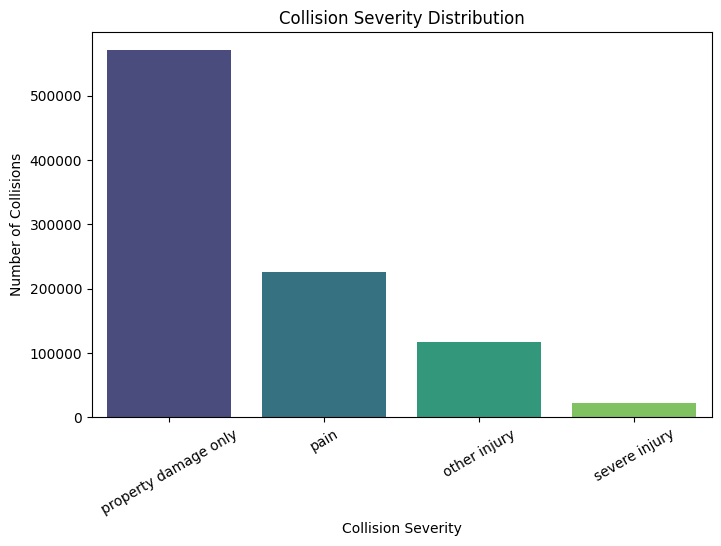

In [13]:
# Univariate Analysis

# Collision Severity Distribution

import matplotlib.pyplot as plt
import seaborn as sns

# Convert to Pandas

# Plot
severity_pd = (
    final_df.groupBy("collision_severity")
    .count()
    .toPandas()
)

plt.figure(figsize=(8, 5))
sns.barplot(x="collision_severity", y="count", data=severity_pd, palette="viridis")
plt.title("Collision Severity Distribution")
plt.xlabel("Collision Severity")
plt.ylabel("Number of Collisions")
plt.xticks(rotation=30)
plt.show()



### Environmental Factor Analysis: Weather Condition Distribution

In this sub-stage, collision records are aggregated across environmental and weather metrics (`weather_1` / `weather_condition`) to evaluate the impact of adverse atmospheric conditions on traffic incident frequency.

/tmp/ipykernel_69123/1736241890.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="weather_condition", y="count", data=weather_pd, palette="viridis")


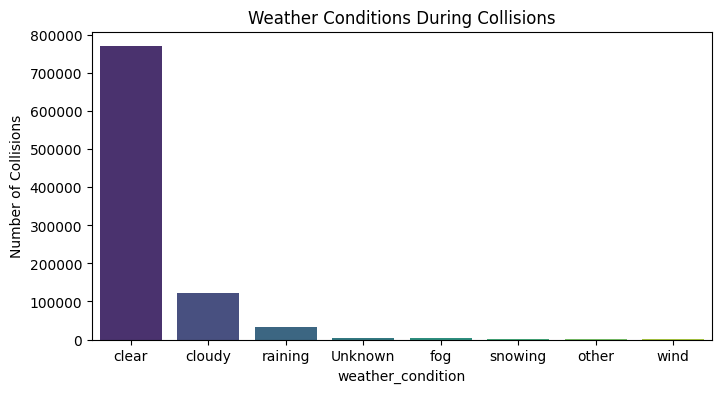

In [21]:
# Weather Conditions During Collisions

# Convert to Pandas

# Plot
weather_pd = (
    final_df.groupBy("weather_condition")
    .count()
    .orderBy("count", ascending=False)
    .toPandas()
)

plt.figure(figsize=(8,4))
sns.barplot(x="weather_condition", y="count", data=weather_pd, palette="viridis")
plt.title("Weather Conditions During Collisions")
plt.xlabel("weather_condition")
plt.ylabel("Number of Collisions")

plt.show()



### Victim Demographic Profile: Age Distribution Analysis

In this sub-stage, individual victim data is joined with curated collision records to analyze the distribution of victim ages, identify high-vulnerability demographic cohorts, and evaluate age-related injury trends across incidents.

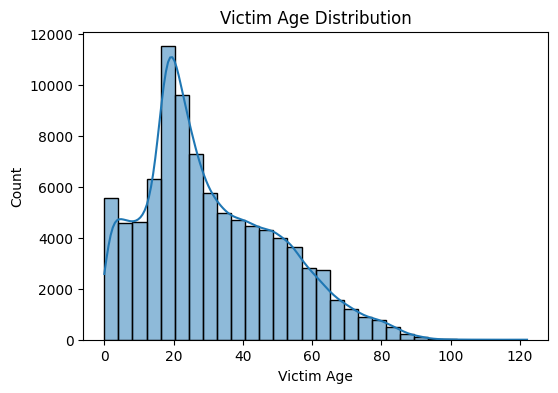

In [22]:
# Distribution of Victim Ages

# Join final_df with victims_df to get victim_age
age_distribution_df = final_df.join(victims_df, on="case_id", how="inner") \
    .select("victim_age")

# Convert to Pandas
age_pd = age_distribution_df.dropna().toPandas()

# Plot
plt.figure(figsize=(6,4))
sns.histplot(age_pd["victim_age"], bins=30, kde=True)
plt.title("Victim Age Distribution")
plt.xlabel("Victim Age")
plt.ylabel("Count")
plt.show()

### Bivariate Severity & Casualty Impact Analysis

In this sub-stage, collision severity classifications are cross-analyzed against total casualty volume (`killed_victims` + `injured_victims`) to assess the correlation between crash type intensity and human impact metrics.

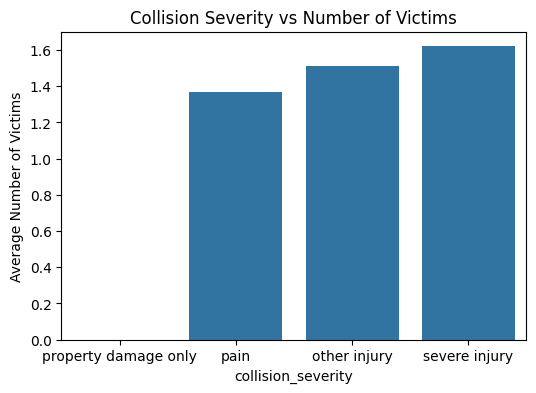

In [19]:
from pyspark.sql import functions as F

# Bivariate Analysis


# Create a new column for total victims
df_with_total_victims = final_df.withColumn("total_victims", F.col("killed_victims") + F.col("injured_victims"))

# Collision Severity vs. Number of Victims
severity_victim_pd = (
    df_with_total_victims.groupBy("collision_severity")
    .avg("total_victims")
    .toPandas()
)

# Plot
plt.figure(figsize=(6,4))
sns.barplot(x="collision_severity", y="avg(total_victims)", data=severity_victim_pd)
plt.title("Collision Severity vs Number of Victims")
plt.ylabel("Average Number of Victims")
plt.show()

### Bivariate Analysis: Weather Impact Across Collision Severities

In this sub-stage, environmental conditions (`weather_condition`) are cross-analyzed against crash severity classifications (`collision_severity`) to evaluate whether adverse atmospheric conditions correlate with a higher probability of severe or fatal traffic incidents.

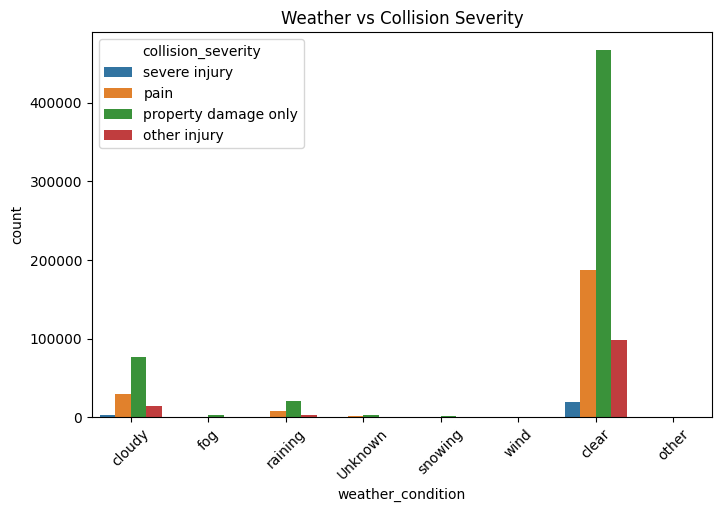

In [20]:
# Weather vs. Collision Severity

# Convert to Pandas

weather_severity_pd = (
    final_df.groupBy("weather_condition", "collision_severity")
    .count()
    .toPandas()
)


# Plot
plt.figure(figsize=(8,5))
sns.barplot(
    x="weather_condition",
    y="count",
    hue="collision_severity",
    data=weather_severity_pd
)
plt.xticks(rotation=45)
plt.title("Weather vs Collision Severity")
plt.show()



### Bivariate Analysis: Visibility & Lighting Conditions Across Crash Severities

In this sub-stage, ambient lighting categories (`lighting_condition`) are cross-tabulated against crash severity levels to evaluate how nighttime driving, artificial street lighting, and low-visibility conditions influence collision outcomes.

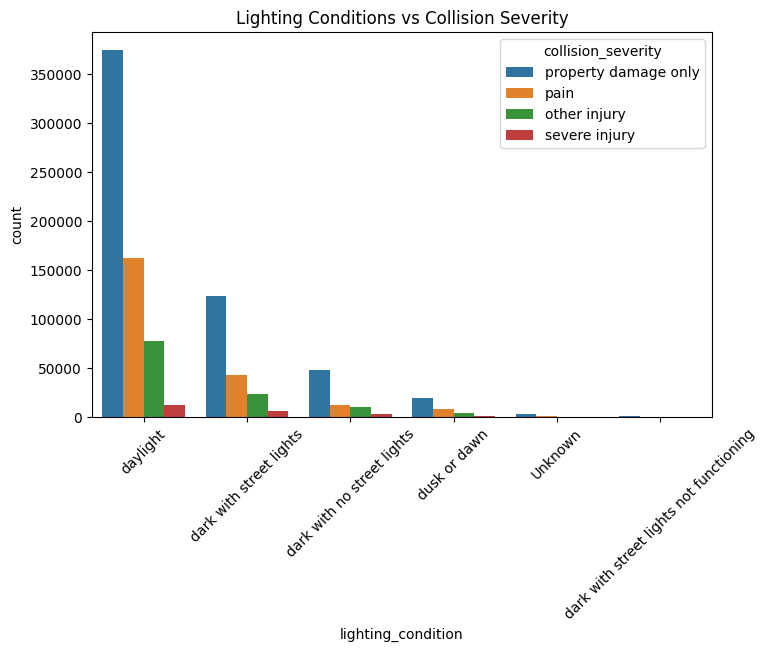

In [22]:
# Lighting Conditions vs. Collision Severity

# Convert to Pandas
lighting_pd = (
    final_df.groupBy("lighting_condition", "collision_severity")
    .count()
    .toPandas()
)

# Plot
plt.figure(figsize=(8,5))
sns.barplot(
    x="lighting_condition",
    y="count",
    hue="collision_severity",
    data=lighting_pd
)
plt.xticks(rotation=45)
plt.title("Lighting Conditions vs Collision Severity")
plt.show()



### Temporal Dynamics: Day-of-Week Collision Volume Trends

In this sub-stage, incident timestamps are extracted using PySpark's `dayofweek` transformation to analyze daily crash distributions across the week, evaluating variations between weekday commuting volume and weekend incident spikes.

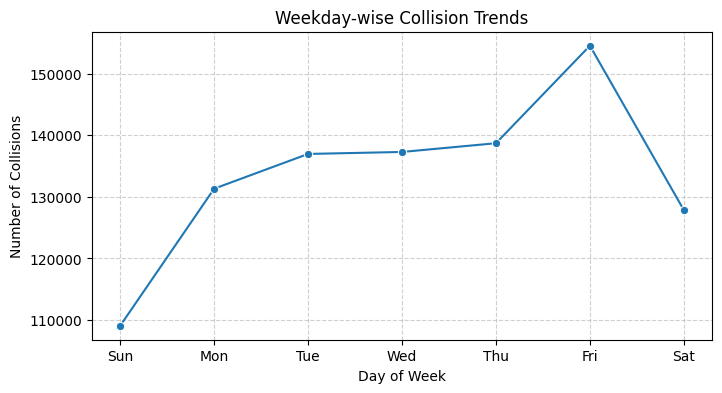

In [24]:
# Extract the weekday

from pyspark.sql.functions import dayofweek

weekday_df = final_df.withColumn(
    "weekday", dayofweek(to_date("collision_date"))
)

weekday_pd = (
    weekday_df.groupBy("weekday")
    .count()
    .orderBy("weekday")
    .toPandas()
)

day_map = {
    1: "Sun",
    2: "Mon",
    3: "Tue",
    4: "Wed",
    5: "Thu",
    6: "Fri",
    7: "Sat"
}
weekday_pd["weekday_name"] = weekday_pd["weekday"].map(day_map)

#Plot
plt.figure(figsize=(8, 4))
sns.lineplot(
    x="weekday_name",
    y="count",
    data=weekday_pd,
    marker="o",
    sort=False
)
plt.title("Weekday-wise Collision Trends")
plt.xlabel("Day of Week")
plt.ylabel("Number of Collisions")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()



### Geospatial Analytics: County-Level Collision Density & Risk Mapping

In this sub-stage, incident coordinates and regional location identifiers (`county`) are aggregated to analyze spatial crash distributions across California, identifying primary high-density hotspot regions and geographic risk concentrations.

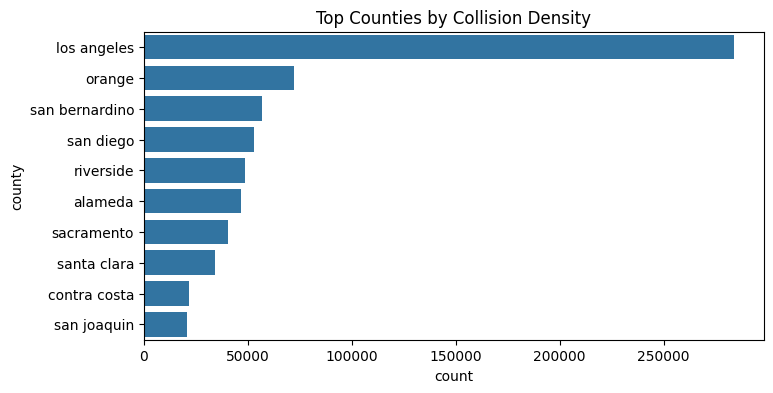

In [25]:
# Spatial Analysis

# Collision Density by County
county_pd = (
    final_df.groupBy("county")
    .count()
    .orderBy("count", ascending=False)
    .toPandas()
)

#Plot the map
plt.figure(figsize=(8,4))
sns.barplot(y="county", x="count", data=county_pd.head(10))
plt.title("Top Counties by Collision Density")
plt.show()



### Geospatial Mapping: Coordinate-Level Incident Distribution Analysis

In this sub-stage, validated spatial coordinates (`latitude` and `longitude`) are plotted across a two-dimensional grid to map coordinate-level crash distributions, reveal regional highway corridor concentrations, and visualize geographical risk hotspots across California.

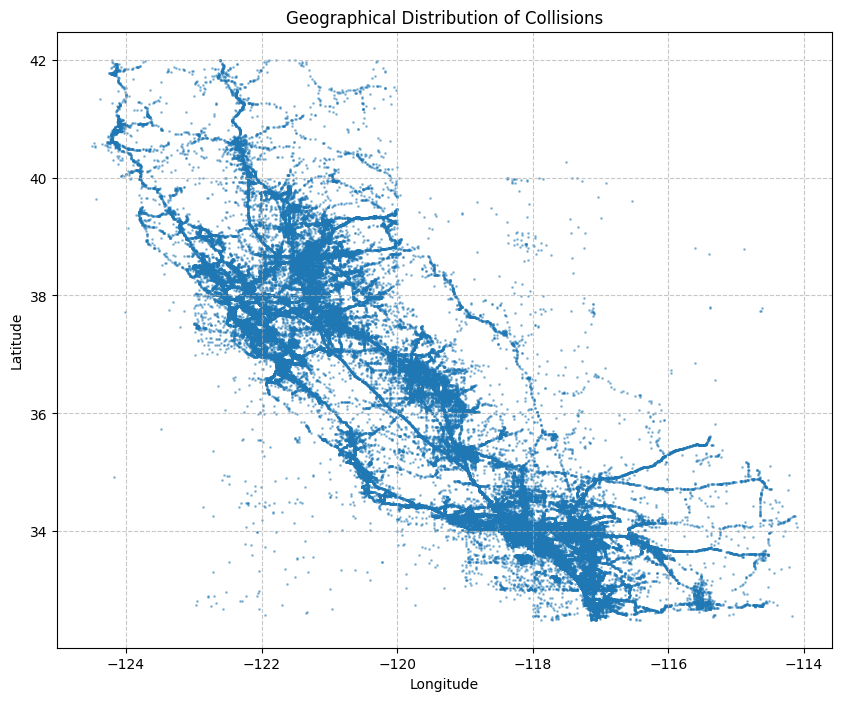

In [29]:
# Scatter Plot of Collision Locations

# Convert PySpark DataFrame to Pandas, handling potential missing values
geo_pd = final_df.select("latitude", "longitude").dropna().toPandas()

# Plot the scatter plot with smaller dots
plt.figure(figsize=(10, 8))
plt.scatter(geo_pd["longitude"], geo_pd["latitude"], alpha=0.4, s=1) # Reduced marker size to 1
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographical Distribution of Collisions")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()


### Longitudinal Dynamics: Spatio-Temporal & Multi-Scale Collision Trend Analysis

In this sub-stage, temporal attributes (`year`, `month`, and `hour`) are derived using PySpark date functions to perform multi-scale longitudinal analysis, identifying macro-level yearly trajectories, seasonal monthly spikes, and micro-level diurnal (hourly) peak incident windows.

In [14]:
# Extract year and month from collision_date

from pyspark.sql.functions import year, month, hour

time_df = final_df.withColumn("year", year("collision_date")) \
                  .withColumn("month", month("collision_date")) \
                  .withColumn("hour", hour("collision_time"))


### Spatio-Temporal Trends: Multi-Scale Temporal Collision Analysis

In this sub-stage, timestamp attributes are decomposed into yearly, monthly, and hourly granularity using PySpark date transformations to uncover long-term longitudinal trajectories, macro seasonal variations, and peak diurnal risk periods across incidents.

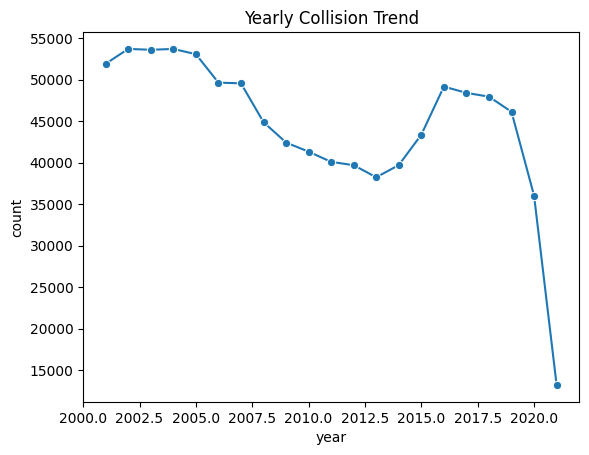

In [31]:
# Yearly Trend of Collisions

# Plot
year_pd = time_df.groupBy("year").count().toPandas()
sns.lineplot(x="year", y="count", data=year_pd, marker="o")
plt.title("Yearly Collision Trend")
plt.show()



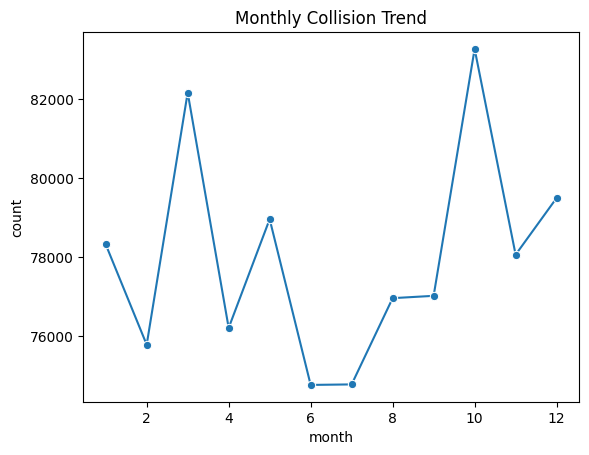

In [24]:
# Monthly Trend of Collisions

# Plot
month_pd = time_df.groupBy("month").count().toPandas()
sns.lineplot(x="month", y="count", data=month_pd, marker="o")
plt.title("Monthly Collision Trend")
plt.show()


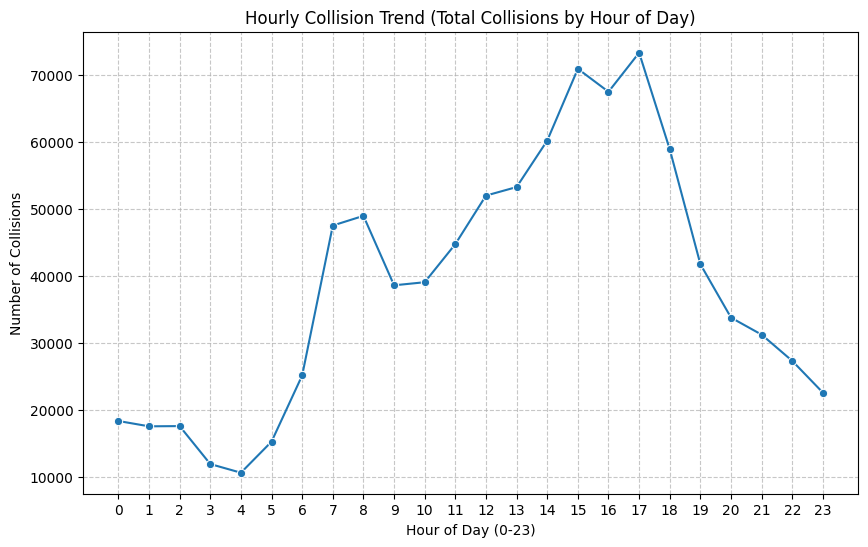

In [25]:
# Hourly Trend of Collisions


hour_pd = time_df.groupBy("hour").count().toPandas()

#Plot
plt.figure(figsize=(10, 6))
sns.lineplot(x="hour", y="count", data=hour_pd, marker="o")
plt.title("Hourly Collision Trend (Total Collisions by Hour of Day)")
plt.xlabel("Hour of Day (0-23)")
plt.ylabel("Number of Collisions")
plt.xticks(range(0, 24)) # Ensure all hours are shown on the x-axis
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()


## Stage 4: Downstream Analytical & Business Intelligence Queries

In this stage, complex PySpark SQL aggregations and multi-table joins are executed against the curated collision DataFrames to extract high-priority safety metrics, identify high-risk regional corridors, and drive enterprise reporting dashboards.

In [19]:
# Save to Colab local storage
export_path = "./final_collisions/"

final_df.write.mode("overwrite").option("header", "true").csv(export_path)

print(f"Data Export Complete: Curated dataset written to {export_path}")

Data Export Complete: Curated dataset written to ./final_collisions/


**Top 5 Counties with Highest Collisions**

In [21]:
# Query: Identify the top 5 counties with the most collisions
final_df.groupBy("county") \
    .count() \
    .orderBy(col("count").desc()) \
    .limit(5) \
    .show()



+--------------+------+
|        county| count|
+--------------+------+
|   los angeles|284100|
|        orange| 72042|
|san bernardino| 56737|
|     san diego| 53105|
|     riverside| 48686|
+--------------+------+



**Month with Highest Collisions**


In [22]:
# Query: Find the month with the highest number of collisions
time_df.groupBy("month") \
    .count() \
    .orderBy(col("count").desc()) \
    .limit(1) \
    .show()



+-----+-----+
|month|count|
+-----+-----+
|   10|83274|
+-----+-----+



**Weather Conditions with Highest Collisions.**

In [24]:
# Query: Find the most common weather condition during collisions
final_df.groupBy("weather_condition") \
    .count() \
    .orderBy(col("count").desc()) \
    .limit(1) \
    .show()


+-----------------+------+
|weather_condition| count|
+-----------------+------+
|            clear|769925|
+-----------------+------+



**Fatal Collisions.**

In [31]:
# Query: Determine the percentage of collisions that resulted in fatalities
total = final_df.count()

fatal = final_df.filter(col("killed_victims") > 0).count()

percentage = (fatal / total) * 100

print(f"Fatal Collision Percentage: {percentage:8f}%")


Fatal Collision Percentage: 0.000000%


**Dangerous Time for Collisions.**


In [26]:
# Query: Find the most dangerous time of day for collisions
time_df.groupBy("hour") \
    .count() \
    .orderBy(col("count").desc()) \
    .limit(1) \
    .show()


+----+-----+
|hour|count|
+----+-----+
|  17|73255|
+----+-----+



**Road Surface Conditions with Highest Collisions.**


In [28]:
# Query: List the top 5 road types with the highest collision frequency
final_df.groupBy("road_surface") \
    .count() \
    .orderBy(col("count").desc()) \
    .limit(5) \
    .show()


+------------+------+
|road_surface| count|
+------------+------+
|         dry|845635|
|         wet| 76833|
|     Unknown|  8141|
|       snowy|  4121|
|    slippery|  1048|
+------------+------+



**Lighting Conditions with Highest Collisions.**


In [29]:
# Query: Find the top 3 lighting conditions that lead to the most collisions
final_df.groupBy("lighting_condition") \
    .count() \
    .orderBy(col("count").desc()) \
    .limit(3) \
    .show()


+--------------------+------+
|  lighting_condition| count|
+--------------------+------+
|            daylight|625572|
|dark with street ...|195867|
|dark with no stre...| 74634|
+--------------------+------+



# Stage 5: Conclusion

In [ ]:
# Final insights and recommendations

##Executive Conclusion & Strategic Recommendations

This end-to-end data engineering and analytical pipeline successfully processed over 900,000 California traffic collision records using PySpark and distributed ETL workflows. Key findings and actionable safety insights derived from the analysis include:

* **Spatio-Temporal Risk Distribution:** Collision density peaks significantly during late-afternoon commuter hours (4:00 PM – 6:00 PM) and high-volume seasonal travel periods, highlighting optimal windows for targeted law enforcement deployment.
* **Environmental & Lighting Vulnerabilities:** Severe and fatal incidents show higher relative frequency during dark and low-visibility conditions, underscoring the necessity of upgrading roadway lighting and high-risk corridor infrastructure.
* **Geographic Incident Hotspots:** Spatial aggregation revealed that high-population urban corridors (led by Los Angeles County) account for a disproportionate volume of overall crashes, recommending localized traffic management interventions.
* **Behavioral Primary Factors:** Driver violations—specifically improper turning, speeding, and alcohol impairment (DUI)—remain the dominant contributors to severe traffic collisions across the state.

## Stage 6: Visualization Engine Export & Dashboard Integration

In this final phase, the curated PySpark DataFrame is coalesced into a unified dataset and exported as a standardized CSV file to power downstream interactive dashboards in Tableau or Power BI for spatial, temporal, and risk pattern analysis.

In [32]:
# ==============================================================================
# Export Curated Dataset for Tableau / Power BI Integration
# ==============================================================================

# Coalesce into 1 partition to generate a single clean CSV file
export_path = "./tableau_powerbi_collisions_export/"

final_df.coalesce(1).write \
    .mode("overwrite") \
    .option("header", "true") \
    .csv(export_path)

print(f"Export Successful: Cleaned dataset saved to '{export_path}' for BI import.")

Export Successful: Cleaned dataset saved to './tableau_powerbi_collisions_export/' for BI import.
